<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#0400ffff'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
- [5. Exploratory Data Analysis (EDA)](#5)
    - [5.1. Feature Relevance](#5_1)
    - [5.2. Sample Analysis](#5_2)
    - [5.3. Initial Data Structure](#5_3)
        - [5.3.1. Overview](#5_3_1)
        - [5.3.2. Missing Values Analysis](#5_3_2)
        - [5.3.3. Duplicates Analysis](#5_3_3)
    - [5.4. Univariate Analysis](#5_4)
        - [5.4.1. Unique Values](#5_4_1)
        - [5.4.2. Numerical Frequency](#5_4_2)
        - [5.4.3. Categorical Frequency](#5_4_3)
        - [5.4.4. Anomalies and Errors](#5_4_4)
        - [5.4.5. Target Feature Analysis (Price)](#5_4_5)
        - [5.4.6. Descriptive Statistics and Visualizations](#5_4_6)
    - [5.5. Bivariate Analysis](#5_5)
        - [5.5.1. Group By Analysis](#5_5_1)
        - [5.5.2. Correlation Matrix (Heatmap)](#5_5_2)
    - [5.6. Multivariate Analysis](#5_6)
        - [5.6.1. Scatterplot 3D](#5_6_1)
        - [5.6.2. Scatter Matrix](#5_6_2)
- [6. End of the Notebook](#6)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#top)
</a>

This project presents the development of a complete machine learning pipeline designed to predict car prices for Cars 4 You, with the purpose of supporting and accelerating the company’s vehicle evaluation process. Starting from the original 2020 dataset provided by the company, a full data exploration stage was conducted, addressing key data quality issues such as missing values, inconsistent formats, outliers, and incorrect data types. 

This notebook represents the start of our project. Throughout, we performed the Exploratory Data Analysis (EDA) process, which is based on analysing the dataset provided, addressing its quality, extracting insights and defining actionables for later cleaning in the Data Preprocessing phase.

During our analysis, we found missing values on all features, a small share of duplicates, a big quantity of misspellings on categorical features and some invalid data. Outliers are very common on most features and year, mileage and engineSize seem to be the most relevant features to predict the car's price.

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#top)
</a>

This section includes the import of the core libraries required for this notebook of the project. In addition, custom .py files containing auxiliary functions developed during the project are imported to support and standardize key steps of the workflow.
These tools support efficient data analysis, visualization and simple manipulation.

In [3]:
# General Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For data manipulation and construction of a dataframe with different lists
from itertools import zip_longest

# Load Created Functions
import sys
sys.path.append("../")

from Source.visualizations import *

# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#top)
</a>

Understanding the features is essential to interpret the data correctly and supports the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and unit of measurement.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#top)
</a>

Here, pd.read_csv() is used to import the files to start the project and converting them into Pandas DataFrames. CarID is set to index since it's the unique identifier in all data sets for each individual car.

In [4]:
# Load datasets
sample = pd.read_csv('../../data/sample_submission.csv')
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

# Set 'carID' as index
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Exploratory Data Analysis (EDA)**

[Back to TOP](#top)
</a>

In this phase, the dataset is explored to identify inconsistencies, missing values, duplicate records, as well as relationships and patterns among variables. This analysis is a crucial foundation for the preprocessing stage, where these issues are addressed and corrected to ensure robust model performance.

<a class="anchor" id="5_1">

## **5.1.** Feature Relevance
[Back to TOP](#top)
</a>

Upon examining the metadata, the feature `paintQuality%` can already be disregarded, as it represents information provided by the mechanic. This corresponds to a stage in the pricing process that the project aims to replace through predictive modeling.
Consequently, this feature is ignored throughout the exploratory analysis and is formally removed during the feature selection stage in the subsequent notebook.

<a class="anchor" id="5_2">

## **5.2.** Sample Analysis
[Back to TOP](#top)
</a>

In this step, the sample dataset is examined. This dataset includes the target variable, price, which the predictive models aim to estimate.

In [5]:
print("Initial Analysis of the Sample Submission Dataset")
print('')
print(sample.shape)
print('-----------------------')
print(sample.head())
print('-----------------------')
print(sample.tail())

Initial Analysis of the Sample Submission Dataset

(32567, 1)
-----------------------
         price
carID         
89856   851000
106581  514000
80886   323000
100174  921000
81376   620000
-----------------------
         price
carID         
105775  412000
81363   441000
76833   684000
91768   835000
99627     2000


In [6]:
print("Continue to analyse the Sample Submission Dataset")
print('------------------------')
print('')
print(sample.info())
print('')
print('------------------------')
print(sample.describe())

Continue to analyse the Sample Submission Dataset
------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   price   32567 non-null  int64
dtypes: int64(1)
memory usage: 508.9 KB
None

------------------------
               price
count   32567.000000
mean   498198.943716
std    288111.809635
min      1000.000000
25%    249000.000000
50%    501000.000000
75%    746000.000000
max    999000.000000


From the analysis performed, it is possible to observe a wide range of values for the target variable, as illustrated by observations 100174 and 99627.

The dataset contains 32,567 entries with no missing values for the target variable, and its distribution appears approximately normal. This is supported by the proximity of the mean and median values, both around 500,000, as well as by the first and third quartiles, which are approximately 250,000 and 750,000, respectively.

<a class="anchor" id="5_3">

## **5.3.** Initial Data Structure
[Back to TOP](#top)
</a>

<a class="anchor" id="5_3_1">

### **5.3.1.** Overview
[Back to TOP](#top)
</a>

In this section, an initial exploration of the training and test datasets is performed to understand their basic structure and content. The first and last ten rows of each dataset are examined, general information about the features is reviewed, and summary statistics are analysed. This initial overview helps identify the overall characteristics of the data and detect any immediate issues prior to more detailed analysis.

In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (75973, 13)
Test shape: (32567, 12)


As expected, the training dataset contains one additional feature, price, which serves as the target variable for model training. The training dataset is also considerably larger than the test dataset, which is beneficial for learning robust predictive patterns.

In [8]:
train.head(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.000000,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.000000,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.000000,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.000000,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.000000,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.700000,2.0,74.0,0.000000,0.0
6924,Audi,A3,2017.0,16089,Manual,21396.000000,Petrol,20.0,60.100000,1.4,75.0,4.000000,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.900000,1.6,59.0,4.000000,0.0
67071,VW,Passat,2017.0,15999,Semi-Auto,30339.000000,Diesel,150.0,62.800000,2.0,85.0,4.000000,0.0


In [9]:
train.tail(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
67221,VW,T-Roc,2020.0,25785,Semi-Auto,10.0,Petrol,145.0,39.80000,1.5,65.0,4.0,0.0
41090,Mercedes,GLC Class,2016.0,24486,NaN,22955.0,Diesel,125.0,56.50000,2.1,72.0,4.0,0.0
16023,Ford,EcoSport,2017.0,10498,Manual,13613.0,Petrol,125.0,88.32164,1.0,57.0,3.0,0.0
60263,Opel,Crossland X,2018.0,13995,Manual,1800.0,Petrol,150.0,57.70000,1.2,69.0,0.0,0.0
44131,Mercedes,GLC Class,2018.0,30495,Semi-Auto,11943.0,Diesel,150.0,56.50000,2.1,74.0,NaN,0.0
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.30000,2.0,78.0,0.0,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.90000,2.0,38.0,2.0,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.00000,1.0,57.0,3.0,0.0
860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.10000,2.0,74.0,2.0,0.0


From the visualization of the head and tail of the dataset, several data quality issues can already be identified:

1. **Missing values** across multiple features;
2. Values in the `Year` and `previousOwners` columns appear as floating point numbers (e.g., 2020.0), although these variables should be represented as integers;
3. The `mpg` feature contains floating point values with inconsistent decimal precision;
3. The `hasDamage` feature is represented as floating point values and appears to contain only zeros, despite being a binary variable;
5. **Negative values** are present in features where they are not meaningful, such as `previousOwners`;
6. **Misspellingsand inconsistent labels** are observed in categorical features, particularly `model` and `fuelType`.

To address the identified problems, the following steps are planned:
1. Perform a detailed analysis of missing values;
2. Assess whether each issue affects a significant number of observations;
3. Standardize and uniformize all values;
4. Correct data types and analyse the valid ranges of numerical features;
5. Evaluate the impact of anomalous values on the dataset;
6. Apply systematic corrections to categorical values during the data preparation stage.

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


From the dataset information, the previously identified incorrect data formats are confirmed and it's observed that all features contain missing values except for the target variable, price.

To gain a complementary perspective on the data distributions and potential anomalies, the analysis is extended using summary statistics obtained with describe().

In [11]:
train.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


From the numerical describe statistics, several data quality issues can be identified:

1. In the `year` feature, the maximum value is approximately 2024, even though the dataset corresponds to vehicles up to the year 2020;
2. Negative values are present in the minimum values of `mileage`, `tax`, `mpg`, `engineSize` and `previousOwners`, which are not meaningful in this context;
3. The `previousOwners` feature is represented as a floating point variable, despite being a discrete count;
4. The `hasDamage` feature is intended to be binary; however, instead of containing values 0 and 1, it includes only 0 and missing values.

To address these issues, the following actions are planned:

1. Disregard values in the year feature that exceed 2020 during the data preparation stage;
2. Quantify the number of negative values in the affected features and determine whether they should be removed or corrected;
3. Assess the prevalence of floating point values in discrete features and decide whether to round or otherwise correct them;
4. Replace missing values in the hasDamage feature with 1 during data preparation, under the assumption that missing entries indicate the presence of damage.

In [12]:
train.describe(include='object').T

,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


Beyond the presence of missing values, the categorical summary statistics reveal a relatively high number of unique categories in several features. Given the inconsistencies already observed during the initial inspection of the data, such as variations in letter casing and spelling errors, this high cardinality is likely not solely due to genuine category diversity, but rather to inconsistently recorded values.

This observation is particularly relevant for features such as model, fuelType or Brand, where minor spelling differences can artificially inflate the number of unique categories. Identifying these issues at this stage is important, as they directly inform the need for categorical value standardization during the data cleaning and preprocessing phases.

<a class="anchor" id="5_3_2">

### **5.3.2.** Missing Values Analysis
[Back to TOP](#top)
</a>

It has already been observed that all features contain missing values. The next step is to assess the severity of this issue and, based on this analysis, determine the most appropriate strategy to be applied during the preprocessing phase. Depending on the extent and nature of the missing data, these values may be addressed through imputation, removal or other preprocessing techniques to ensure the dataset is suitable for modeling.
To support this analysis, a custom function was developed to compute the percentage of missing values per feature. This function, saved in a .py file, is reused later during the imputation stage to ensure consistency throughout the preprocessing workflow.

In [13]:
missing_values_table(train)

,Feature,Missing_Percent
0,mpg,10.432654
1,tax,10.403696
2,previousOwners,2.040198
3,hasDamage,2.037566
4,paintQuality%,2.005976
5,transmission,2.003343
6,Brand,2.002027
7,model,1.996762
8,engineSize,1.995446
9,fuelType,1.988864


Although all features except the target variable contain missing values, the proportion of missing data is relatively low across all columns. As a result, all features are considered worth retaining.

In order to preserve as many observations as possible, the option of removing incomplete records is also disregarded. Instead, missing values are addressed through imputation. The specific imputation method is selected at a later stage based on its impact on model performance.

<a class="anchor" id="5_3_3">

### **5.3.3.** Duplicates Analysis
[Back to TOP](#top)
</a>

At this stage, the dataset is examined for duplicate entries. Identifying and removing duplicates is important to prevent bias and to ensure that each observation contributes uniquely to the analysis and model training process.
Additionally, duplicates in the dataset index are also checked, as the carID feature is used as the index. Ensuring index uniqueness is essential to maintain data integrity throughout the analysis.

In [14]:
print(f"The duplicates without the index is: {train.duplicated().sum()}") 
print(f"The percentages of duplicates is: {(train.duplicated().sum()/len(train) * 100).round(4)}%")
print('')
print(f"The duplicates in carID (defined as index) is: {train.index.has_duplicates}")

The duplicates without the index is: 4
The percentages of duplicates is: 0.0053%

The duplicates in carID (defined as index) is: False


From the analysis above, it is concluded that four records contain duplicated values associated with different identifiers. As these duplicates may represent data entry errors and account for only 0.0053% of the dataset and given that no duplicates are present in the index, these records are removed from the dataset.

In [15]:
train = train.drop_duplicates()

<a class="anchor" id="5_4">

## **5.4.** Univariate Analysis and Data Quality
[Back to TOP](#top)
</a>

In this section, each feature is analysed individually to understand its distribution and main characteristics. This analysis helps identify patterns, outliers, and potential data quality issues within each variable.

<a class="anchor" id="5_4_1">

### **5.4.1.** Unique Values
[Back to TOP](#top)
</a>

All unique values in each feature are examined to assess data diversity, identify categorical variables and detect features with little or no variability that may be less informative for modeling.

In [16]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Brand': ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
-----------------------------------

Unique values on the column 'model': [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' E

The results obtained reinforce the data quality issues previously identified during the exploratory analysis. At this stage, the focus shifts toward extracting more detailed, different and valuable insights that will later support a comprehensive and systematic data correction and preprocessing process.

<a class="anchor" id="5_4_2">

### **5.4.2.** Numerical Frequency
[Back to TOP](#top)
</a>

In this section, the frequency of specific values within numerical features is analysed. Although these variables are quantitative, examining their value counts helps uncover patterns that may not be evident from summary statistics alone. In particular, this analysis supports the identification of discrete behaviour, potential data entry errors and dominant or recurring values.

In [17]:
for column in train.select_dtypes(include=['number']).columns:
    count_values = train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: \n{count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'year' is: 
year
2019.000000    20270
2017.000000    16144
2016.000000    11502
2018.000000    10303
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2001.000000       15
2011.111188       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count

<a class="anchor" id="5_4_3">

### **5.4.3.** Categorical Frequency
[Back to TOP](#top)
</a>

In this section, the frequency of values within categorical features is analysed. This analysis helps identify dominant categories, rare values and inconsistencies such as misspellings or variations in representation, which are not always evident from summary statistics alone.

In [18]:
for column in train.select_dtypes(include=['object']).columns:
    vc = train[column].value_counts(dropna=False)
    print(f"--- {column} (n_unique={vc.shape[0]}) ---")
    display(vc.head(10))


--- Brand (n_unique=73) ---


Brand
Ford        14806
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
Audi         6749
Toyota       4289
Skoda        3973
Hyundai      3064
NaN          1521
Name: count, dtype: int64

--- model (n_unique=736) ---


model
 Focus       6351
 C Class     4886
 Fiesta      4130
 Golf        3081
 Corsa       2182
 Polo        2046
 Astra       1744
 A Class     1618
 3 Series    1566
NaN          1517
Name: count, dtype: int64

--- transmission (n_unique=41) ---


transmission
Manual       38048
Semi-Auto    15545
Automatic    14001
NaN           1522
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Name: count, dtype: int64

--- fuelType (n_unique=35) ---


fuelType
Petrol    37992
Diesel    28474
Hybrid     2042
NaN        1511
PETROL      795
etrol       794
Petro       785
petrol      746
iesel       603
diesel      599
Name: count, dtype: int64

The following observations summarize the main issues identified across individual features:

- **Brand:**
Exhibits significant inconsistencies related to letter casing (e.g., 'FOR'), misspellings (e.g., 'mercede'), and fragmented entries (e.g., 'pel', 'udi'), indicating a need for categorical standardization;

- **Model:**
Shows a high number of variations caused by leading and trailing spaces, inconsistent casing, typographical errors (e.g., 'Focu' instead of 'Focus'), and incomplete entries (e.g., 'A Clas'). This feature is particularly affected by data quality issues;

- **year:**
Contains fractional values (e.g., 2023.36707842), suggesting encoding errors or floating-point artifacts. Additionally, as identified earlier, values exceeding 2020 represent inconsistencies that require correction;

- **price:**
Appears to be purely numeric and displays appropriate variability, with no evident data quality issues at this stage.
transmission
Includes multiple variants and typographical errors for common categories (e.g., 'Manual', 'manua', 'anual'), as well as 'Unknown' entries that require further handling;

- **mileage:**
Appears mostly clean and numeric, with no major issues detected during this analysis.

- **fuelType:**
Presents several spelling and casing inconsistencies (e.g., 'Petrol', 'petrol', 'etrol'), indicating the need for normalization.

- **tax:**
Contains suspicious negative and fractional values that are not meaningful in this context and must be addressed during preprocessing.

- **mpg:**
Displays potential outliers and invalid negative values that warrant further investigation.

- **engineSize:**
Includes unexpected negative and zero values, which should be verified and corrected to ensure realistic engine capacity ranges.

- **previousOwners:**
Contains negative values, fractional counts, and missing values, all of which are inconsistent with the nature of this feature.

- **hasDamage:**
Represents a binary indicator but includes only values of 0 and missing entries, suggesting that missing values may encode the presence of damage.

<a class="anchor" id="5_4_4">

### **5.4.4.** Anomalies and Errors

[Back to TOP](#top)
</a>

It was previously observed that some values in the dataset contain errors, such as negative values in features that should only take positive numbers, or percentages greater than 100%, which are logically impossible. In the next step, these invalid values are analyzed in more detail by calculating their counts and proportions to understand how they may impact the model's predictions.

In [19]:
# Boolean masks for negative values in numeric columns
mileage_negatives = train['mileage']<0
tax_negatives = train['tax']<0
mpg_negatives = train['mpg']<0
engineSize_negatives = train['engineSize']<0
previousOwners_negatives = train['previousOwners']<0


# Summary DataFrame of negative values in numeric columns
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_negatives.value_counts(),
    'tax_negatives': tax_negatives.value_counts(),
    'mpg_negatives': mpg_negatives.value_counts(),
    'engineSize_negatives': engineSize_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_negatives.value_counts()
})

negatives_summary

,mileage_negatives,tax_negatives,mpg_negatives,engineSize_negatives,previousOwners_negatives
False,75600,75591,75933,75885,75598
True,369,378,36,84,371


In [20]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

# Calculate percentage of negatives in each numeric column
negatives_percent = {
    'mileage_negatives (%)': mileage_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_negatives.sum() / data_len * 100
}

# Convert to DataFrame
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

,mileage_negatives (%),tax_negatives (%),mpg_negatives (%),engineSize_negatives (%),previousOwners_negatives (%)
Percentage of Negatives,0.486,0.498,0.047,0.111,0.488


Most observations derived from the analysis above had already been identified during the preliminary exploratory phase. Based on these findings, the following corrective actions are defined for each feature:

- **Brand, model, transmission, and fuelType:**
Standardize capitalization and spacing, and correct spelling errors and inconsistent representations.

- **year:**
Convert values to integers, handle or remove nonsensical decimal values, and discard entries greater than 2020.

- **mileage, tax, mpg, engineSize, and previousOwners:**
Address negative values by treating them as missing where appropriate, or correcting them when clearly caused by data entry errors. Decimal values in discrete features such as previousOwners are verified and rounded accordingly.

- **hasDamage:**
Investigate missing values and recode them as 1, since the feature contains only zeros and is intended to represent a binary indicator.

In addition to these feature-specific corrections, all missing values previously identified in the dataset are addressed during the preprocessing stage.

<a class="anchor" id="5_4_5">

### **5.4.5.** Target Analysis

[Back to TOP](#top)
</a>

In this subsection, the characteristics of the target variable, price, are examined. As the target exhibits a right skewed distribution with a wide range of values, the logarithmic transformation of the price (log(price)) is also analysed.
Applying a logarithmic transformation helps stabilize variance and reduce the influence of extreme values, allowing patterns in the data to be more clearly observed. In addition, analysing the target on a log scale facilitates interpretation in terms of relative or percentage changes rather than absolute differences. This approach is particularly appropriate for economic and financial variables, which often follow multiplicative relationships.

Price skew: 2.284
Log(price) skew: -0.144


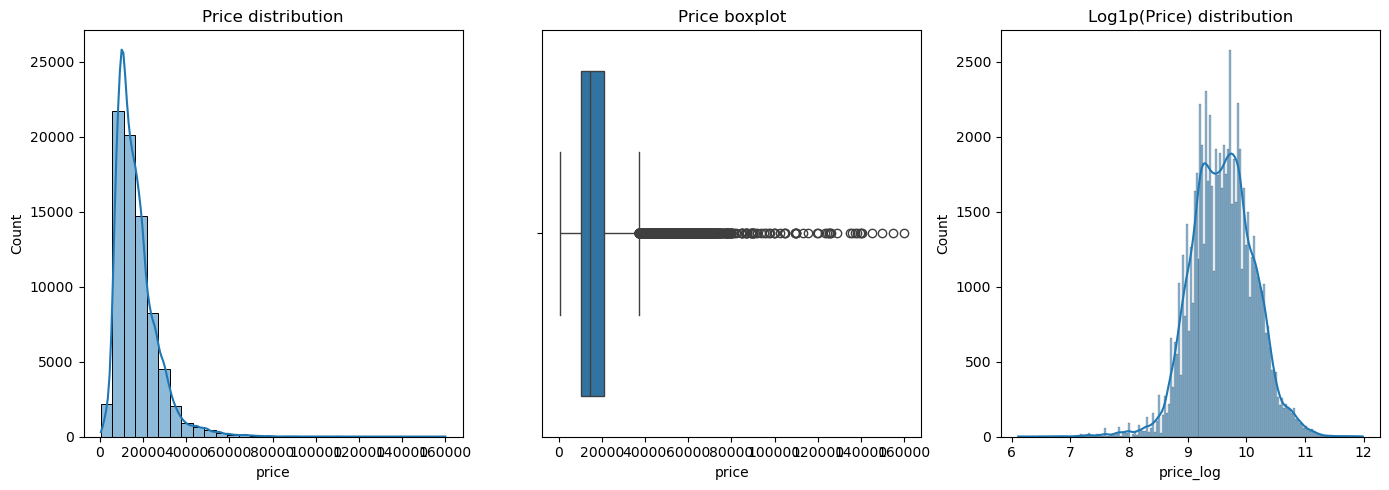

In [21]:
# Distribution & Transform
train['price_log'] = np.log1p(train['price'])

# Statistics
# Calculate skewness, which measures how asymmetric the data distribution is
print("Price skew:", train['price'].skew().round(3)) 
print("Log(price) skew:", train['price_log'].skew().round(3))

# Plots
fig, axes = plt.subplots(1,3, figsize=(14,5))
sns.histplot(train['price'], bins=30, ax=axes[0], kde=True)

axes[0].set_title('Price distribution')
sns.boxplot(x=train['price'], ax=axes[1])
axes[1].set_title('Price boxplot')

# Also plot log-price
sns.histplot(train['price_log'], ax=axes[2], kde=True)
axes[2].set_title('Log1p(Price) distribution')

plt.tight_layout()
plt.show()

The distribution of price is highly right skewed, with the majority of observations concentrated at lower values and a long tail extending toward higher prices, as evidenced by both the histogram and the boxplot. This pattern indicates the presence of numerous extreme values and a clear deviation from normality, which may negatively affect model performance if the target variable is used in its original scale.

After applying a logarithmic transformation, the distribution becomes substantially more symmetric and closer to a normal shape. This transformation reduces the influence of extreme values and stabilizes variance, making the target variable more suitable for linear models and other methods that rely on distributional assumptions. Additionally, modeling the logarithm of price enables interpretation of results in terms of relative or percentage changes rather than absolute price differences, which is more meaningful in most economic and financial contexts.

<a class="anchor" id="5_4_6">

### **5.4.6** Descriptive Statistics and Visualizations

[Back to TOP](#top)
</a>

This section begins by categorizing the features into metric (discrete and continuous) and non-metric types. Subsequently, the dataset's main characteristics are summarized using descriptive statistics and visualizations. This process is crucial for understanding distributions, trends, and potential anomalies, providing insights that guide further analysis and modeling decisions.

NOTE: As established in section 5.1, the feature PaintQuality% is excluded from the descriptive statistics and visualizations below.

In [22]:
# Separate the features
metric_features = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize','previousOwners']
non_metric_features = ['brand', 'model', 'transmission', 'fuelType', 'hasDamage']

continuous_features = ['price', 'mileage', 'tax', 'mpg', 'engineSize']
discrete_features = ['year', 'previousOwners']

# Organize the new lists in a table to better visualize them
data = list(zip_longest(
    metric_features,
    non_metric_features,
    continuous_features,
    discrete_features,
    fillvalue=""
))

headers = [
    "Metric Features",
    "Non-Metric Features",
    "Continuous Features",
    "Discrete Features"
]

df_table = pd.DataFrame(data, columns=headers)
print(df_table.to_string(index=False))


Metric Features Non-Metric Features Continuous Features Discrete Features
           year               brand               price              year
          price               model             mileage    previousOwners
        mileage        transmission                 tax                  
            tax            fuelType                 mpg                  
            mpg           hasDamage          engineSize                  
     engineSize                                                          
 previousOwners                                                          


#### **Histograms**

Histograms are used to examine the distribution of continuous features. These plots allow for visualizing the shape of the data, detect skewness, and identifying potential outliers or patterns in the feature values.

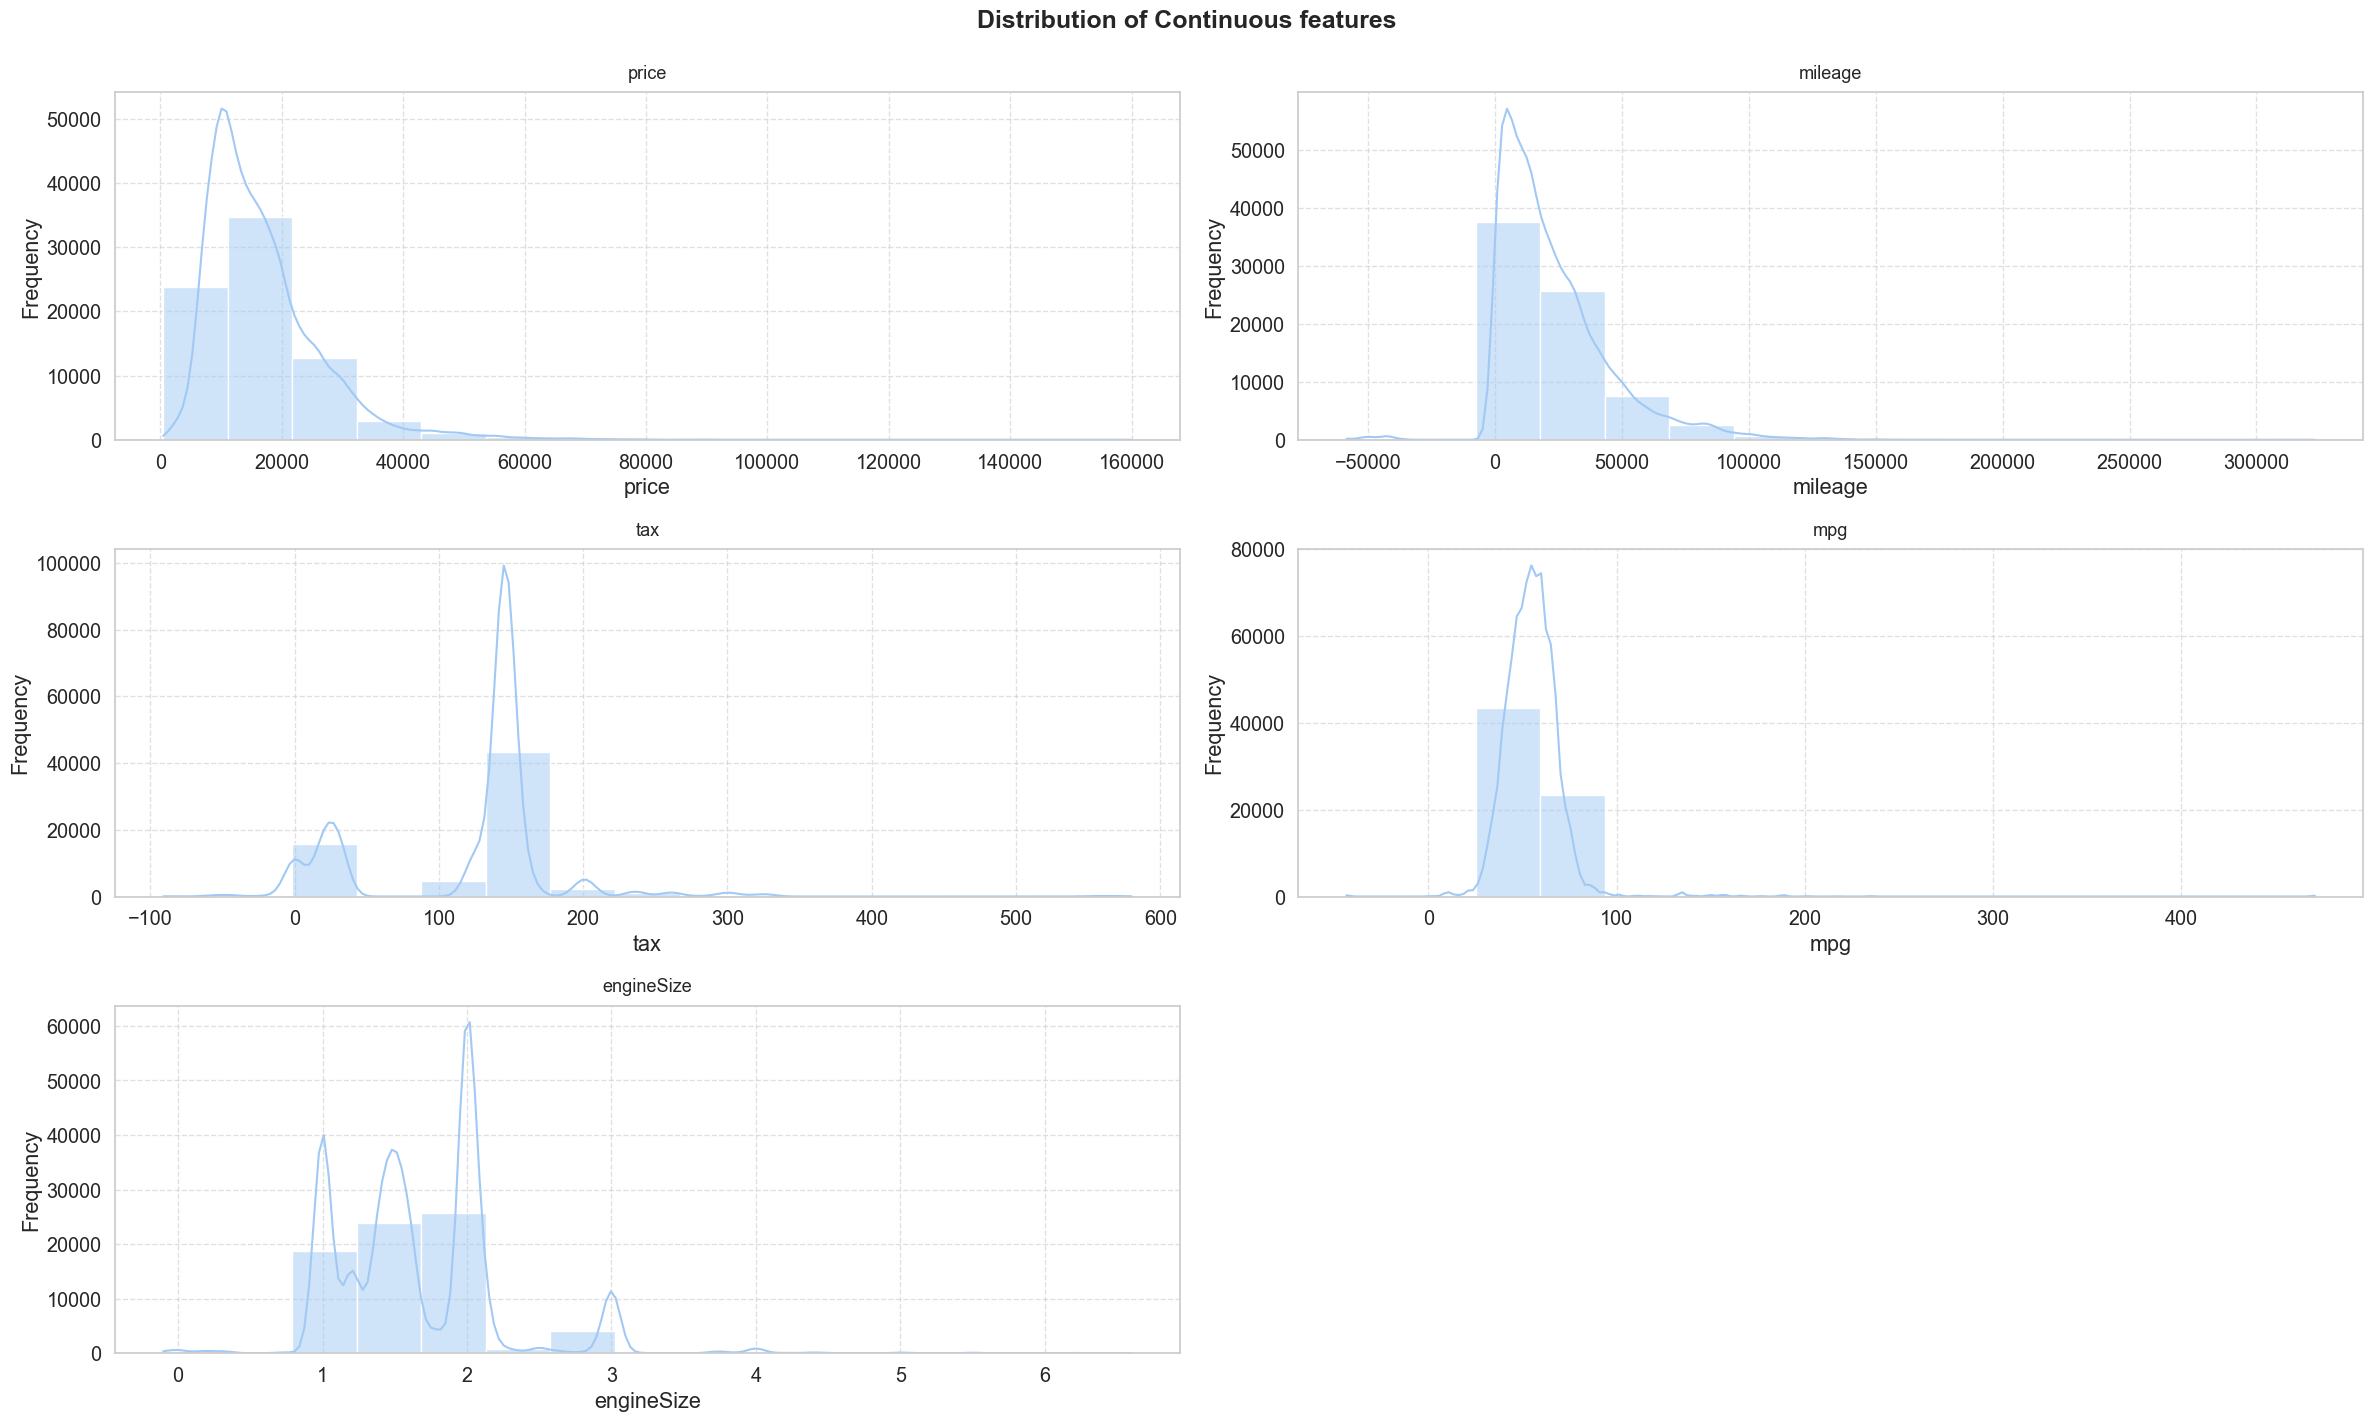

In [23]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 3, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 15))

# Plot data
# Iterate across axes objects and associate each histogram
for ax, feat in zip(axes.flatten(), continuous_features):
    kde_flag = True
    sns.histplot(data=train, x=feat, bins=15, kde=kde_flag, ax=ax)
    ax.set_title(feat, fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.6)

# Turn off unused subplots
for ax in axes.flatten()[len(continuous_features):]:
    ax.axis('off')

# General Layout
fig.suptitle("Distribution of Continuous features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


Based on the evaluation of the histograms, it is possible to state that:

`Price` - The distribution is strongly right-skewed, most cars are low or mid-priced, but a few luxury vehicles inflate the tail. Some prices are extreme outliers, possibly due to rare high-end models. From here we can say that the market is dominated by affordable vehicles.

`Mileage` - Also right-skewed, which is expected. Most used cars have moderate mileage, and a few have very high values. The histogram visually confirms the presence of erroneous negative values.

`Tax` - Sharp peak around a specific value (≈150–200), indicating standardized taxation rates for most vehicles. Some negative or zero values are also noticed.

`Mpg` - Distribution shows that most cars cluster around 20 to 90 miles per gallon , with few very high or very low values, the negative values being incorrect.

`EngineSize` - Multiple peaks, possibly due to different engine categories (1.0L, 1.5L, 2.0L, etc.). The pattern may reflect distinct market segments.

#### **BarPlots**

Bar plots are used to examine the distribution of discrete features. These graphs facilitate the visualization of the data's shape, allowing for the detection of skewness, potential outliers and specific patterns within the feature values.

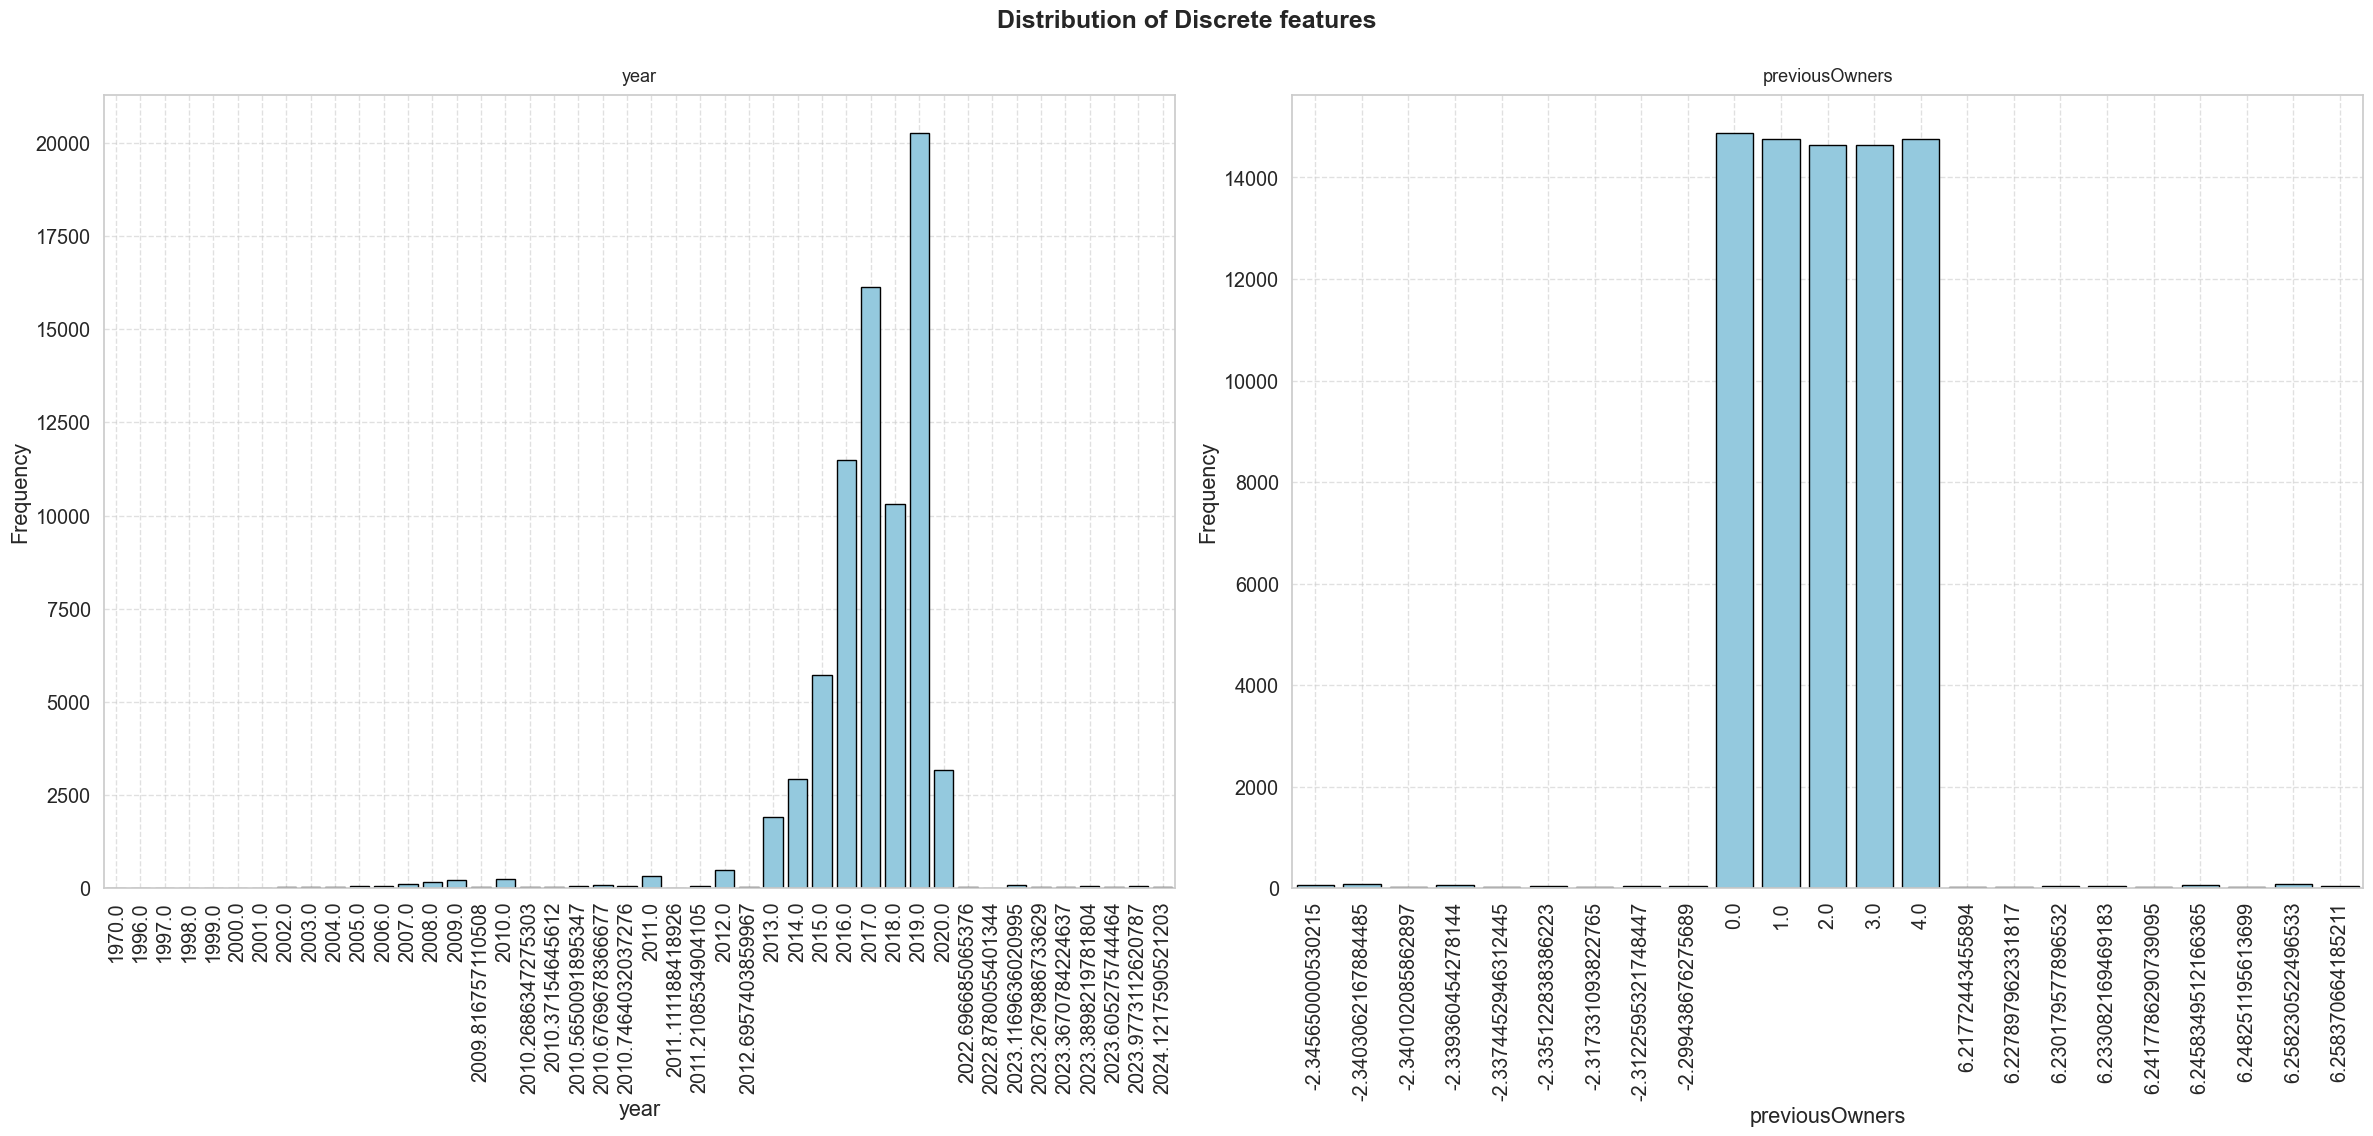

In [24]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 1, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 12))

# Plot data
for ax, feat in zip(axes.flatten(), discrete_features):
    sns.countplot(data=train, x=feat, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f"{feat}", fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.set_xlabel(feat)
    ax.tick_params(axis='x', rotation=90) # Rotate x-axis labels for better readability
    ax.grid(True, linestyle="--", alpha=0.6)

fig.suptitle("Distribution of Discrete features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


Based on the visualization of the discrete features, the following patterns are observed:

`Year` - The distribution is heavily skewed towards recent years, with the majority of vehicles registered between 2015 and 2020. This indicates a dataset dominated by modern cars. However, the presence of outliers (extremely old cars or potential errors) is visible in the lower tail.

`PreviousOwners` - The plot visually confirms the data inconsistencies previously identified. The x-axis explicitly displays floating-point numbers and negative values, which are logically impossible for a count of owners. Despite these errors, it is evident that the majority of the valid data is concentrated between 0 and 4 owners.

#### **Boxplots** (Outliers Detection)

Boxplots are employed to visualize the spread and variability of numerical features. These plots highlight the median, quartiles, and outliers, facilitating the detection of unusual values and the understanding of the overall data distribution.

Given that boxplots are a recurrent visualization throughout this analysis, a custom function was developed and stored in an external .py file. This ensures that all plots maintain a consistent structure and styling.

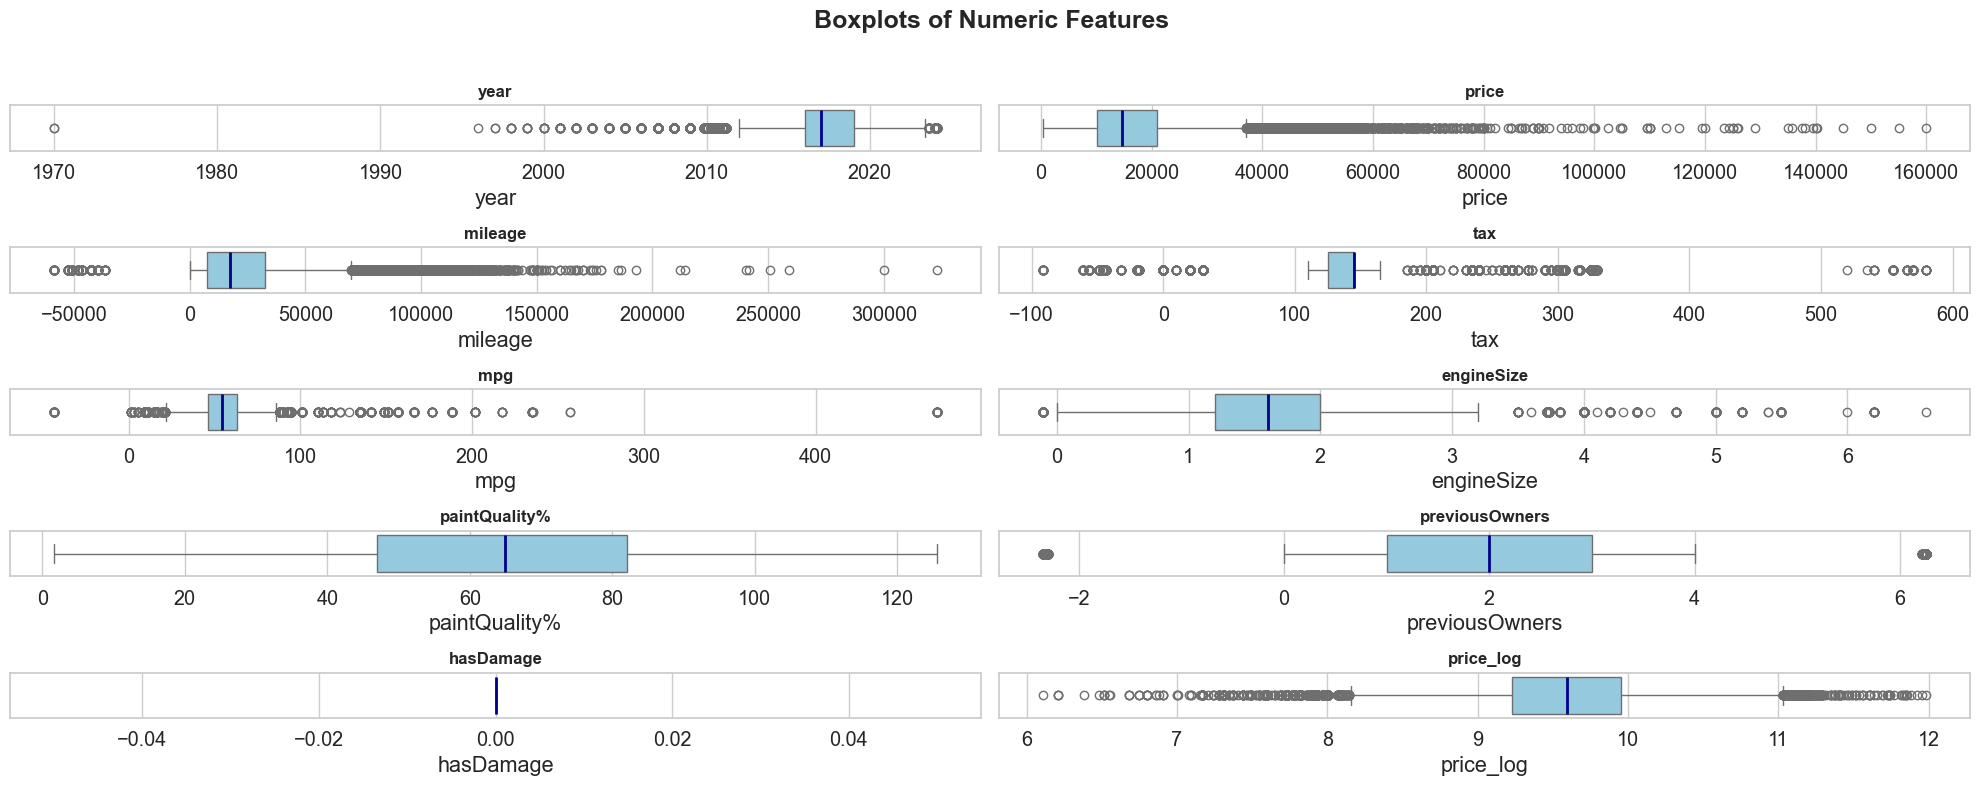

In [25]:
# Call the function
create_boxplots(train)

Based on the boxplots shown above, it can be observed that:

`Year` - The distribution is left-skewed, with a wide range of outliers from the mid-1990s to the early 2000s. We can also clearly see invalid values appearing after the year 2020.

`Price`- This boxplot is right-skewed, with a large proportion of outliers ranging approximately from £40,000 up to £160,000, showing a wide interval compared to the main body of the data.

`Mileage` - Mileage displays a positively skewed distribution with several high-value outliers and a negative value appears in the data.

`Tax`- The distribution is concentrated around specific values but includes some outliers. It has also negative values what makes no sense.

`Mpg`- The distribution is mostly concentrated but includes both low and very high outliers. Some extreme values, such us those above 200 mpg are unrealistic and will be validated. Has also negative values that make no sense and represent errors that need to be treated later.

`EngineSize`- The boxplot shows most engines concentrated between 1.0 and 2.0L, with several larger values appearing as outliers.

`PreviousOwners`- The distribution is concentrated between 1 and 3 owners, with a few outliers, including cars with more than 6 owners and some negative values.

<a class="anchor" id="5_5">

## **5.5.** Bivariate Analysis
[Back to TOP](#top)
</a>

In this section, the relationship between pairs of features is examined, with particular emphasis on the relationship between each predictor and the target variable. This analysis helps assess how individual features may influence the target and whether meaningful associations or correlations are present.

<a class="anchor" id="5_5_1">

### **5.5.1.** GroupBy Analysis
[Back to TOP](#top)
</a>

Groupby operations are used to summarize and compare data across different categories. This approach allows the analysis of how numerical features vary between groups, the identification of relevant patterns and the exploration of relationships that may be important for modeling.

In [26]:
print(train.groupby('hasDamage')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('year')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('previousOwners')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('Brand')['price'].mean())


hasDamage
0.0    16883.327287
Name: price, dtype: float64
--------------------------------------------------------
year
1970.000000    17747.000000
1996.000000     3000.000000
1997.000000     6972.500000
1998.000000    10183.800000
1999.000000     3986.000000
2000.000000     3869.166667
2001.000000     4401.000000
2002.000000     3206.920000
2003.000000     3452.517241
2004.000000     4179.914286
2005.000000     3007.468750
2006.000000     3958.580645
2007.000000     3454.910569
2008.000000     3913.069620
2009.000000     4141.008772
2009.816757    19686.486486
2010.000000     5016.514523
2010.268635    12568.100000
2010.371546    24268.114286
2010.565009    11370.425532
2010.676968    12834.268293
2010.746403    18257.810345
2011.000000     6771.940252
2011.111188    13038.466667
2011.210853    22981.640000
2012.000000     7601.456067
2012.695740    12633.095238
2013.000000     8503.491062
2014.000000    10025.783276
2015.000000    11654.296180
2016.000000    13357.350287
2017.000000 

The average price of vehicles without reported damage is approximately 16,883. While it would be informative to compare this value with vehicles that have reported damage, such a comparison is not possible at this stage due to the absence of explicit information for damaged vehicles.It is also evident that vehicle price varies with the year of manufacture: in general, older cars tend to have lower prices, reflecting the expected effect of depreciation.

Regarding the number of previous owners, no substantial differences are observed in the average price across categories.
Finally, when analysing the average price by brand, clear differences emerge. For example, vehicles from brands such as Hyundai tend to have lower average prices compared to brands like Audi, indicating brand-related price differentiation.

<a class="anchor" id="5_5_2">

### **5.5.2.** Correlation Matrix (Heatmap)
[Back to TOP](#top)
</a>

This section focuses on analysing the relationships between numerical features using correlation measures. This analysis is important for identifying strongly related variables, detecting potential multicollinearity, and understanding how features may influence each other and the target variable.

In [27]:
numeric_features = train[['year', 'mileage', 'price', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
numeric_features.corr(method="pearson").round(3)

,year,mileage,price,tax,mpg,engineSize,paintQuality%,previousOwners
year,1.000,-0.669,0.476,0.179,-0.123,-0.038,0.004,0.000
mileage,-0.669,1.000,-0.405,-0.202,0.167,0.099,-0.001,0.002
price,0.476,-0.405,1.000,0.297,-0.286,0.612,0.000,-0.000
tax,0.179,-0.202,0.297,1.000,-0.419,0.257,0.006,0.003
mpg,-0.123,0.167,-0.286,-0.419,1.000,-0.227,-0.003,-0.001
engineSize,-0.038,0.099,0.612,0.257,-0.227,1.000,0.005,0.001
paintQuality%,0.004,-0.001,0.000,0.006,-0.003,0.005,1.000,-0.006
previousOwners,0.000,0.002,-0.000,0.003,-0.001,0.001,-0.006,1.000


From the numerical correlation matrix alone, it is difficult to draw clear conclusions. To address this, the relationships between features are visualized using heatmaps, which provide an intuitive overview of both the strength and direction of correlations. This representation makes it easier to identify strongly correlated features and overall patterns in the data.

Heatmaps based on both `Pearson` and `Spearman` correlation coefficients are used. Pearson correlation measures linear relationships between variables, while Spearman correlation captures monotonic relationships and is less sensitive to non linearities and outliers. In the same way of boxplots, a function was created to help us plotting the heatmaps.

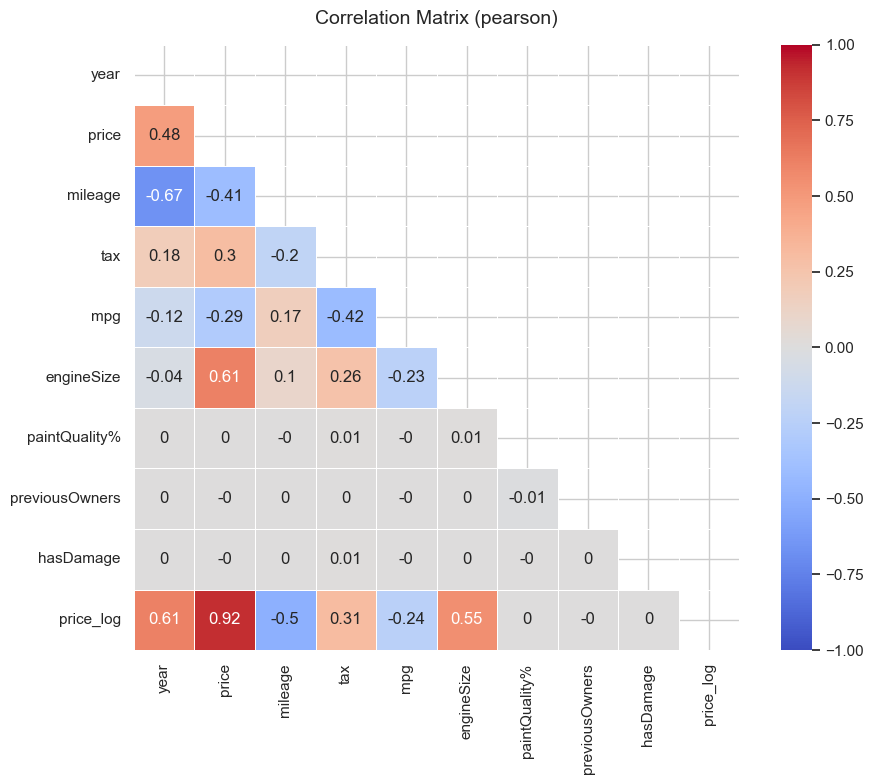

In [44]:
create_heatmap(train, method="pearson", figsize=(10, 8))

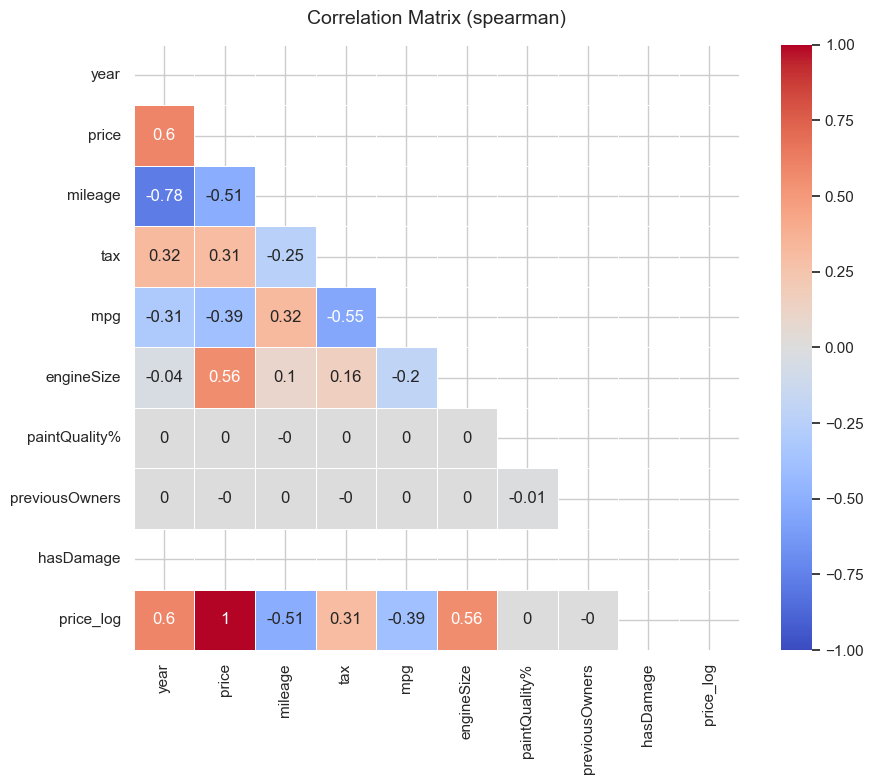

In [29]:
create_heatmap(train, method="spearman")

Based on the correlation analysis using both Spearman and Pearson coefficients, it's possible to identify the potential influence of numerical features on the target variable (price):

- **year, mileage and engineSize** show the strongest relationships with price and are therefore likely to be among the most informative predictors.

- **tax and mpg** exhibit moderate correlations with the target and may provide additional, secondary predictive power.

- **previousOwners and hasDamage** display very weak or negligible correlations with price in their current form, suggesting limited usefulness unless these features are further cleaned, transformed, or reinterpreted.

These observations provide an initial indication of feature relevance but do not imply causality. They are used primarily to guide subsequent preprocessing, feature engineering, and feature selection steps.

<a class="anchor" id="5_6">

## **5.6.** Multivariate Analysis
[Back to TOP](#top)
</a>

In this section, the interactions between multiple features are examined simultaneously. The objective is to identify more complex relationships and combined effects that may not be apparent when features are analysed individually.

<a class="anchor" id="5_6_1">

### **5.6.1.** Scatterplot 3D
[Back to TOP](#top)
</a>

To further explore interactions between multiple numerical features, three dimensional scatter plots are used. These visualizations allow the joint relationship between the target variable and two predictors to be examined simultaneously, providing a more comprehensive view of how combined feature effects influence vehicle prices.

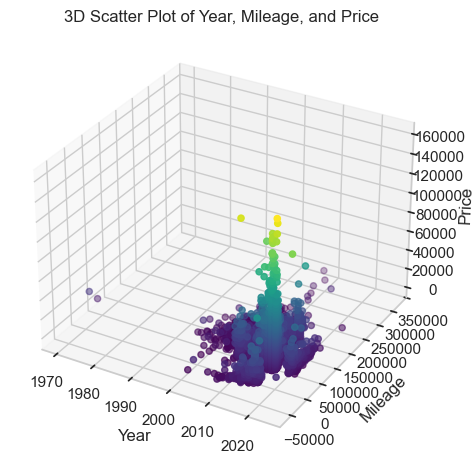

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(train['year'], train['mileage'], train['price'], c=train['price'], cmap='viridis')
ax.set_xlabel('Year')
ax.set_ylabel('Mileage')
ax.set_zlabel('Price')

plt.title('3D Scatter Plot of Year, Mileage, and Price')
plt.tight_layout()
plt.show()


The three-dimensional analysis of Year, Mileage, and Price demonstrates that vehicle depreciation follows a cone-shaped pattern within the valid data range. Recent models (2015-2020) and low mileage vehicles are concentrated at the top of the price spectrum, while older vehicles converge toward a minimum value floor regardless of accumulated use.

The pattern reveals three distinct depreciation dynamics: extreme sensitivity to mileage in recent vehicles, moderate depreciation in intermediate age cars, and price stagnation in older models. Crucially, Year and Mileage do not act independently but through a multiplicative interaction, where the impact of mileage is amplified in newer cars and negligible in older ones.

This explains the limitation of simple linear models and suggests that interaction features and logarithmic transformations are necessary to improve predictive accuracy. Finally, the visualization confirms the presence of erroneous data points (years > 2020) which do not fit the depreciation logic and must be removed rather than treated as statistical outliers.

<a class="anchor" id="5_6_2">

### **5.6.2.** Scatter Matrix
[Back to TOP](#top)
</a>

This visualization illustrates the relationships between pairs of continuous features selected from price, year, mileage, engineSize, and mpg, while distinguishing observations by fuel type.

Each scatter plot depicts how two features interact, whereas the plots along the main diagonal show the individual distributions of each variable.

This representation provides an initial visual assessment of how these features relate to car pricing and helps identify which variables are likely to be most relevant for predicting the target variable.

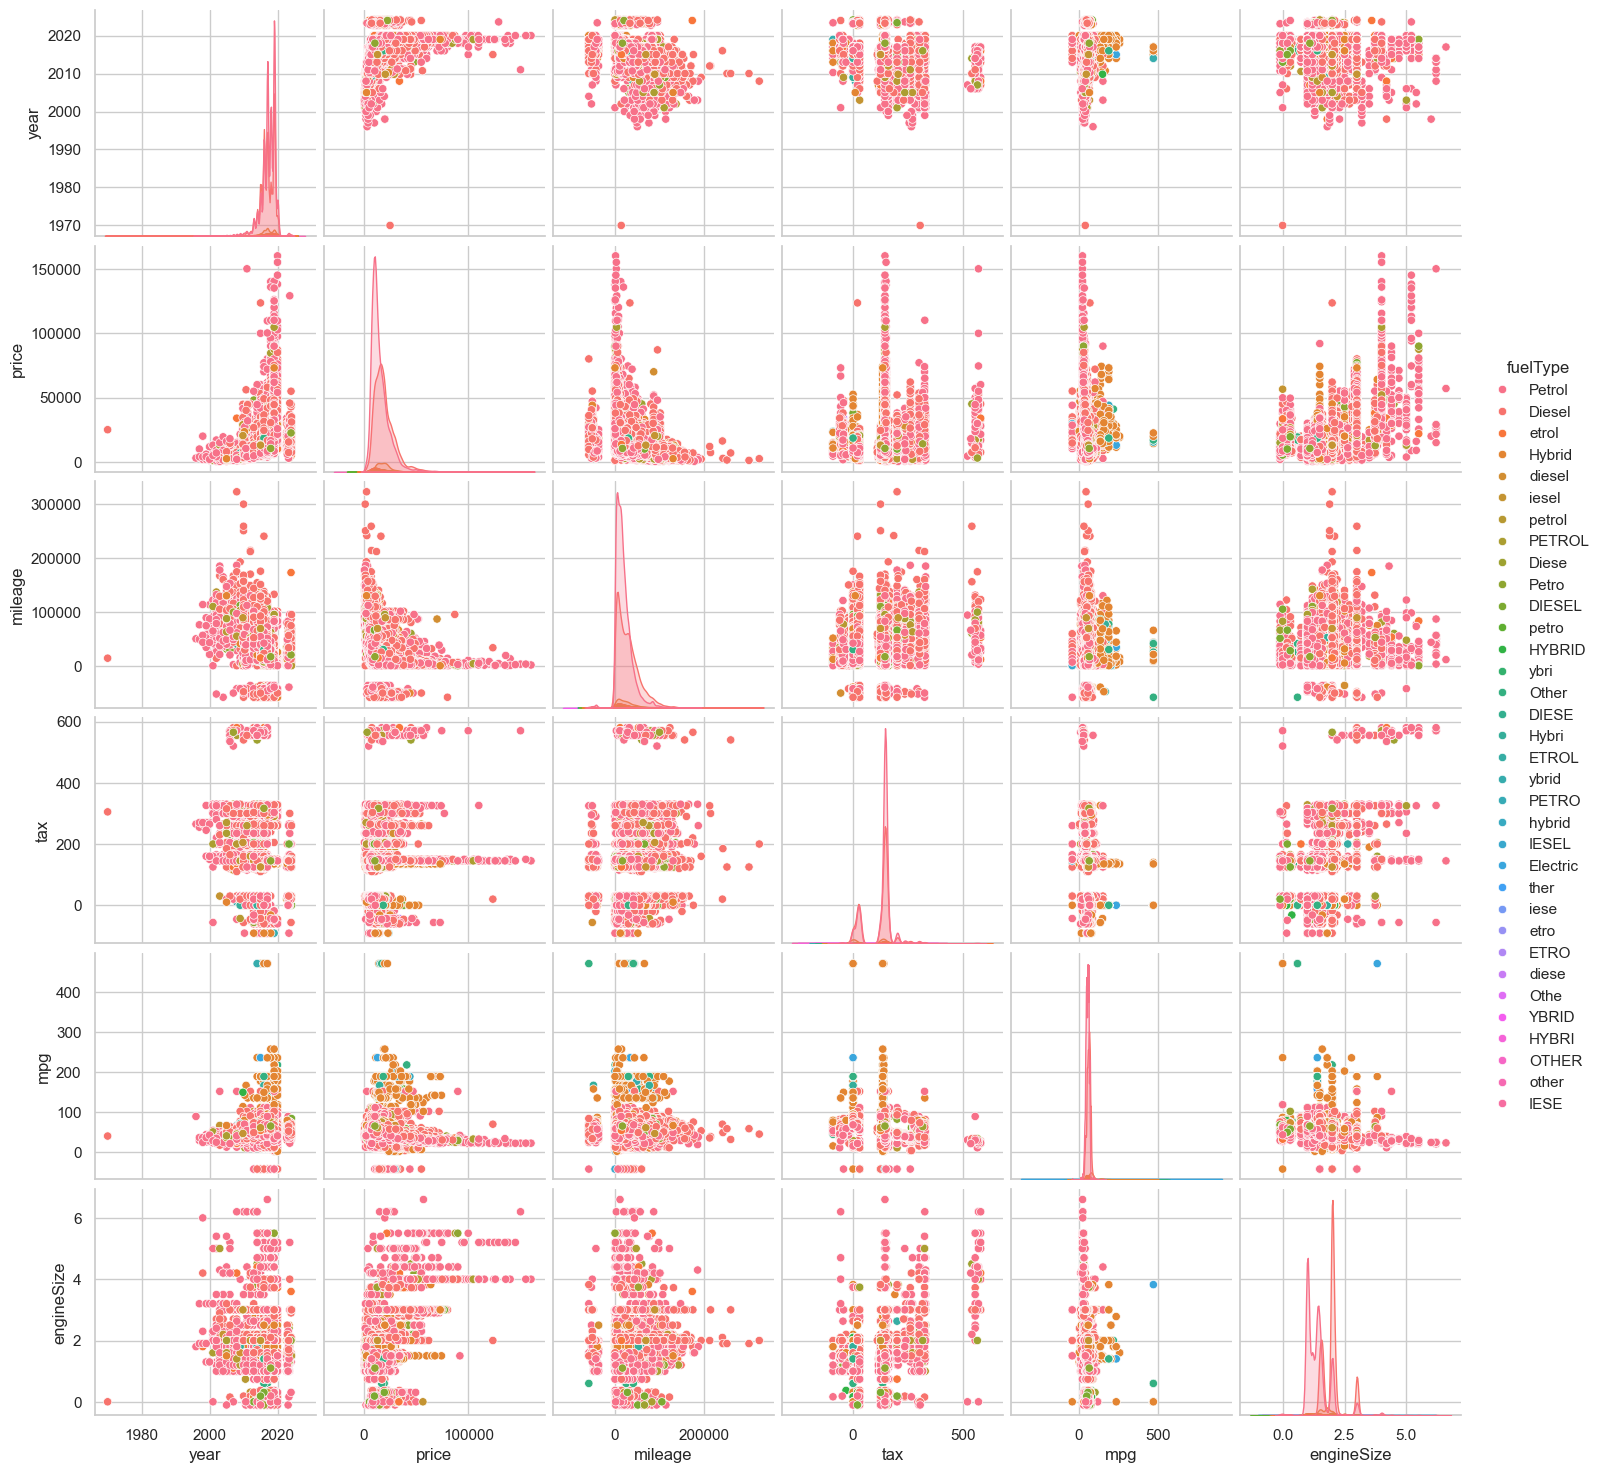

In [48]:
sns.pairplot(train, vars=['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], hue='fuelType')
plt.show()

The conclusions drawn from this scatter matrix are largely consistent with those obtained in the previous pairplot analysis. The relationships between price, year, and mileage remain clearly visible, reinforcing the dominant role of these numerical features in explaining price variation.
While fuel type is included as a categorical dimension in this visualization, the presence of substantial spelling inconsistencies and fragmented categories limits the interpretability of any fuel-type-specific patterns at this stage. As a result, no strong or reliable conclusions can be drawn regarding the effect of fuel type on price from this analysis alone.
This observation further highlights the importance of categorical data cleaning and standardization before attempting to interpret or model category-level effects.

From this visualization, several patterns related to price can be identified:

- Vehicles with lower mileage tend to have higher prices;

- Newer cars are generally more expensive, reflecting the expected effect of depreciation over time;

- Cars with larger engine sizes tend to be more expensive, although they have a high range of prices;

- Tax does not appear to be a strong standalone predictor of price.

Additional bivariate relationships are also observed:
- A negative relationship between engine size and fuel efficiency (mpg), indicating that larger engines generally consume more fuel;

- Newer vehicles tend to be associated with lower tax values and higher fuel efficiency, reflecting improvements in automotive technology and emissions standards;

- The fuelType feature shows a clear predominance of petrol powered vehicles. However, the presence of multiple spelling variations highlights the need for categorical data standardization before meaningful fuel type specific conclusions can be drawn.

Overall, the dataset exhibits expected vehicle valuation patterns, while also revealing outliers and data inconsistencies that must be addressed to ensure more reliable analysis and modeling.

<a class="anchor" id="6">

# **6. End of the Notebook**

[Back to TOP](#top)
</a>

This notebook is exclusive for exploratory data analysis and provided crucial insights for the next steps of the project. Significant data quality issues were identified, including inconsistencies in features like brand and model, incorrect data types, and anomalies such as negative values and erroneous years (e.g., values >2020). Additionally, while missing values are present in low percentages, significant outliers were detected in price and mileage.

Regarding feature relationships, a strong positive correlation was observed between year and price, confirming that newer cars are significantly more expensive. Conversely, higher mileage typically reduces value. Engine size demonstrates a positive relationship with price, suggesting that larger engines often indicate performance vehicles, while fuel-efficient cars tend to be cheaper. Also, it was determined that paint quality is not relevant to the purpose of this project and will be removed in the next stage.

Based on the issues and patterns identified, the subsequent notebook will focus on Data Preprocessing. This includes data cleaning, handling missing values, outlier treatment, feature engineering, encoding, and scaling. Finally, the process will conclude with feature selection, followed by modeling and model comparison.